In [1]:
!pip install ultralytics opencv-python matplotlib numpy pandas pillow

In [3]:
from ultralytics import YOLO
print("YOLO installed successfully!")

YOLO installed successfully!


In [4]:
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolov8n.pt")

# Test on a sample image
results = model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    show=True
)

print("Detection completed!")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 C:\Users\Swastik\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 127.4ms
Speed: 5.1ms preprocess, 127.4ms inference, 24.5ms postprocess per image at shape (1, 3, 640, 480)
Detection completed!


In [5]:
import os
os.makedirs("dataset", exist_ok=True)
print("Dataset folder created successfully!")

Dataset folder created successfully!


In [6]:
import torch
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No NVIDIA GPU detected. Training will use CPU.")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [7]:
from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset
print("Ultralytics ready")

Ultralytics ready


In [8]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
print("YOLO model loaded successfully")


YOLO model loaded successfully


In [9]:
from ultralytics import YOLO
# Check available datasets and training setup
print("Ready for dataset preparation")

Ready for dataset preparation


In [10]:
import os
folders = ["dataset/images/train","dataset/images/val","dataset/labels/train","dataset/labels/val","models","outputs"]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
print("Project folders created successfully!")

Project folders created successfully!


In [11]:
from ultralytics.utils.downloads import download
print("Ultralytics ready for dataset setup")

Ultralytics ready for dataset setup


In [12]:
from ultralytics.utils.downloads import download
download("http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar")

Unzipping C:\Users\Swastik\VOCtrainval_11-May-2012.tar to C:\Users\Swastik...


In [13]:
import os
print(os.listdir())

['.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'bus.jpg', 'Contacts', 'Cookies', 'dataset', 'DIGIT.ipynb', 'Documents', 'Downloads', 'FA-KES-Dataset (1).csv', 'FA-KES-Dataset.csv', 'FAKENEWS.ipynb', 'Favorites', 'g_606_developers.h5', 'JUPYTER1.ipynb', 'JUPYTER2.ipynb', 'Links', 'Local Settings', 'models', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{7ea337d1-4afe-11f0-9fda-a010b0d50d85}.TM.blf', 'NTUSER.DAT{7ea337d1-4afe-11f0-9fda-a010b0d50d85}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{7ea337d1-4afe-11f0-9fda-a010b0d50d85}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'outputs', 'PrintHood', 'PROJECT.ipynb', 'PROJECT1.ipynb', 'Recent', 'runs', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Videos', 'VOCdevkit', 'VOCtrainval_11-May-2012.tar', 'yolov8n.pt']


In [14]:
import os
images_path = "VOCdevkit/VOC2012/JPEGImages"
annotations_path = "VOCdevkit/VOC2012/Annotations"
print("Total Images:", len(os.listdir(images_path)))
print("Total XML Files:", len(os.listdir(annotations_path)))

Total Images: 17125
Total XML Files: 17125


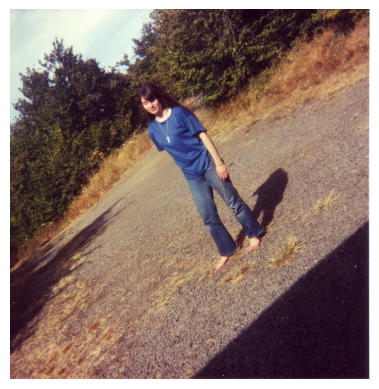

In [15]:
import cv2
import matplotlib.pyplot as plt
image_path = os.path.join(images_path, os.listdir(images_path)[0])
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.show()

In [16]:
sample_image = os.listdir(images_path)[:5]
print("Sample Images:")
for img in sample_image:
    print(img)

Sample Images:
2007_000027.jpg
2007_000032.jpg
2007_000033.jpg
2007_000039.jpg
2007_000042.jpg


In [17]:
import xml.etree.ElementTree as ET
import os
xml_file = os.path.join(annotations_path, os.listdir(annotations_path)[0])
tree = ET.parse(xml_file)
root = tree.getroot()
print("Image Name:", root.find("filename").text)
for obj in root.findall("object"):
    print("Object:", obj.find("name").text)

Image Name: 2007_000027.jpg
Object: person


In [19]:
import os
import xml.etree.ElementTree as ET
from collections import Counter
class_counts = Counter()
for xml_file in os.listdir(annotations_path):
    tree = ET.parse(os.path.join(annotations_path, xml_file))
    root = tree.getroot()

    for obj in root.findall("object"):
        class_name = obj.find("name").text
        class_counts[class_name] += 1
print(class_counts)

Counter({'person': 17401, 'chair': 3056, 'car': 2492, 'dog': 1598, 'bottle': 1561, 'cat': 1277, 'bird': 1271, 'pottedplant': 1202, 'sheep': 1084, 'boat': 1059, 'aeroplane': 1002, 'tvmonitor': 893, 'sofa': 841, 'bicycle': 837, 'horse': 803, 'motorbike': 801, 'diningtable': 800, 'cow': 771, 'train': 704, 'bus': 685})


In [20]:
print("Total Classes:", len(class_counts))
print(sorted(class_counts.keys()))

Total Classes: 20
['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


In [21]:
import xml.etree.ElementTree as ET

def convert_box(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]

    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0

    w = box[1] - box[0]
    h = box[3] - box[2]

    x *= dw
    w *= dw
    y *= dh
    h *= dh

    return (x, y, w, h)

print("Function created successfully!")

Function created successfully!


In [22]:
import os

label_dir = "dataset/labels"

os.makedirs(label_dir, exist_ok=True)

print("Labels folder ready!")

Labels folder ready!


In [23]:
classes = [
    'aeroplane','bicycle','bird','boat','bottle',
    'bus','car','cat','chair','cow',
    'diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]

print("Total Classes:", len(classes))

Total Classes: 20


In [24]:
import os
import xml.etree.ElementTree as ET

xml_folder = "VOCdevkit/VOC2012/Annotations"
txt_folder = "dataset/labels"

os.makedirs(txt_folder, exist_ok=True)

for xml_file in os.listdir(xml_folder):

    tree = ET.parse(os.path.join(xml_folder, xml_file))
    root = tree.getroot()

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    txt_filename = xml_file.replace(".xml", ".txt")

    with open(os.path.join(txt_folder, txt_filename), "w") as f:

        for obj in root.findall("object"):

            class_name = obj.find("name").text

            if class_name not in classes:
                continue

            class_id = classes.index(class_name)

            xmlbox = obj.find("bndbox")

            xmin = float(xmlbox.find("xmin").text)
            xmax = float(xmlbox.find("xmax").text)
            ymin = float(xmlbox.find("ymin").text)
            ymax = float(xmlbox.find("ymax").text)

            x, y, w, h = convert_box(
                (width, height),
                (xmin, xmax, ymin, ymax)
            )

            f.write(f"{class_id} {x} {y} {w} {h}\n")

print("VOC XML converted to YOLO TXT successfully!")

VOC XML converted to YOLO TXT successfully!


In [25]:
import os

txt_files = os.listdir("dataset/labels")

print("Total YOLO Label Files:", len(txt_files))
print("First 5 Files:")
print(txt_files[:5])

Total YOLO Label Files: 17129
First 5 Files:
['2007_000027.txt', '2007_000032.txt', '2007_000033.txt', '2007_000039.txt', '2007_000042.txt']


In [26]:
sample_file = os.path.join("dataset/labels", txt_files[0])

with open(sample_file, "r") as f:
    print(f.read())

14 0.5380658436213992 0.452 0.360082304526749 0.5



In [27]:
import os
import random
import shutil

images_folder = "VOCdevkit/VOC2012/JPEGImages"
labels_folder = "dataset/labels"

train_images = "dataset/images/train"
val_images = "dataset/images/val"

train_labels = "dataset/labels/train"
val_labels = "dataset/labels/val"

os.makedirs(train_images, exist_ok=True)
os.makedirs(val_images, exist_ok=True)
os.makedirs(train_labels, exist_ok=True)
os.makedirs(val_labels, exist_ok=True)

image_files = [f for f in os.listdir(images_folder) if f.endswith(".jpg")]

random.shuffle(image_files)

split = int(0.8 * len(image_files))

train_files = image_files[:split]
val_files = image_files[split:]

print("Train Images:", len(train_files))
print("Validation Images:", len(val_files))

Train Images: 13700
Validation Images: 3425


In [29]:
for img in train_files:

    shutil.copy(
        os.path.join(images_folder, img),
        os.path.join(train_images, img)
    )

    txt = img.replace(".jpg", ".txt")

    if os.path.exists(os.path.join(labels_folder, txt)):
        shutil.copy(
            os.path.join(labels_folder, txt),
            os.path.join(train_labels, txt)
        )

for img in val_files:

    shutil.copy(
        os.path.join(images_folder, img),
        os.path.join(val_images, img)
    )

    txt = img.replace(".jpg", ".txt")

    if os.path.exists(os.path.join(labels_folder, txt)):
        shutil.copy(
            os.path.join(labels_folder, txt),
            os.path.join(val_labels, txt)
        )

print("Dataset split completed successfully!")

Dataset split completed successfully!


In [30]:
print("Train Images:", len(os.listdir(train_images)))
print("Validation Images:", len(os.listdir(val_images)))

print("Train Labels:", len(os.listdir(train_labels)))
print("Validation Labels:", len(os.listdir(val_labels)))

Train Images: 17105
Validation Images: 9083
Train Labels: 17105
Validation Labels: 9083


In [31]:
yaml_content = """
path: dataset

train: images/train
val: images/val

names:
  0: aeroplane
  1: bicycle
  2: bird
  3: boat
  4: bottle
  5: bus
  6: car
  7: cat
  8: chair
  9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor
"""

with open("dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")

data.yaml created successfully!


In [32]:
with open("dataset/data.yaml", "r") as f:
    print(f.read())


path: dataset

train: images/train
val: images/val

names:
  0: aeroplane
  1: bicycle
  2: bird
  3: boat
  4: bottle
  5: bus
  6: car
  7: cat
  8: chair
  9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor



In [33]:
print("Train Images:", len(os.listdir("dataset/images/train")))
print("Validation Images:", len(os.listdir("dataset/images/val")))

Train Images: 17105
Validation Images: 9083


In [35]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="dataset/data.yaml",
    epochs=10,
    imgsz=640,
    batch=8,
    device=0
)

Ultralytics 8.4.66  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

In [6]:
import os

print(os.listdir("runs/detect"))

['train', 'train-10', 'train-11', 'train-2', 'train-3', 'train-4', 'train-5', 'train-6', 'train-7', 'train-8', 'train-9']


In [7]:
import os

for folder in os.listdir("runs/detect"):
    path = f"runs/detect/{folder}/weights"
    if os.path.exists(path):
        print(folder, "->", os.listdir(path))

train -> []
train-10 -> []
train-11 -> ['best.pt', 'last.pt']
train-2 -> []
train-3 -> []
train-4 -> []
train-5 -> []
train-6 -> ['best.pt', 'last.pt']
train-7 -> ['best.pt', 'last.pt']
train-8 -> ['best.pt', 'last.pt']
train-9 -> []


In [8]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-11/weights/best.pt")

metrics = model.val()

print(metrics)

Ultralytics 8.4.66  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 30.027.8 MB/s, size: 106.5 KB)
val: Scanning C:\Users\Swastik\dataset\labels\val.cache... 9083 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 9083/9083  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 568/568 4.3it/s 2:110.2ss
                   all       9083      21163      0.769      0.677      0.754      0.577
             aeroplane        386        544      0.853      0.827      0.856       0.66
               bicycle        316        433      0.684      0.633       0.69      0.544
                  bird        435        737      0.844       0.71      0.818      0.597
                  boat        277        506      0.766      0.561      0.672      0.456
                bottl

In [9]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-11/weights/best.pt")

results = model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    save=True,
    conf=0.25
)

print("Prediction completed!")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 C:\Users\Swastik\bus.jpg: 640x480 1 bus, 3 persons, 116.5ms
Speed: 5.8ms preprocess, 116.5ms inference, 5.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Users\Swastik\runs\detect\predict
Prediction completed!


In [1]:
from ultralytics import YOLO

model = YOLO("runs/detect/train-11/weights/best.pt")

model.predict(source="bus.jpg", show=True)


image 1/1 C:\Users\Swastik\bus.jpg: 640x480 1 bus, 3 persons, 106.6ms
Speed: 3.2ms preprocess, 106.6ms inference, 45.6ms postprocess per image at shape (1, 3, 640, 480)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle', 5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow', 10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike', 14: 'person', 15: 'pottedplant', 16: 'sheep', 17: 'sofa', 18: 'train', 19: 'tvmonitor'}
 obb: None
 orig_img: array([[[119, 146, 172],
         [121, 148, 174],
         [122, 152, 177],
         ...,
         [161, 171, 188],
         [160, 170, 187],
         [160, 170, 187]],
 
        [[120, 147, 173],
         [122, 149, 175],
         [123, 153, 178],
         ...,
         [161, 171, 188],
         [160, 170, 187],
         [160, 170, 187]],
 
        [[123, 150, 176],
         [124, 151, 177],
         [125, 155, 180],
         ...,
         [161, 171, 188],
         [160, 170, 187],
         [160, 170, 187]],
 
        ...,
 
        [[183, 182, 186],
     

In [5]:
from ultralytics import YOLO

image_path = input("Enter image path: ")

model = YOLO("runs/detect/train-11/weights/best.pt")

results = model.predict(
    source=image_path,
    show=True
)

for r in results:
    for c in r.boxes.cls.tolist():
        print("Detected:", r.names[int(c)])

Enter image path:  test_images/car.jpg



image 1/1 C:\Users\Swastik\test_images\car.jpg: 448x640 1 car, 46.9ms
Speed: 5.0ms preprocess, 46.9ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)
Detected: car


In [6]:
pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------- ----- 786.4/914.9 kB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 3.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------- -------------------- 1.0/2.2 MB 5.6 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.2 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 4.1 MB/s  0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------

In [9]:
!jupyter notebook --version

7.5.7


In [10]:
import ipywidgets as widgets
from IPython.display import display

btn = widgets.Button(description="Test Button")
display(btn)

Button(description='Test Button', style=ButtonStyle())

In [11]:
!pip install --upgrade notebook ipywidgets

  Using cached notebook-7.5.7-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_server-2.19.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached jupyterlab-4.5.8-py3-none-any.whl.metadata (16 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached jupyter_events-0.12.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached jupyter_server_terminals-0.5.4-py3-none-any.whl.metadata (5.9 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached prometheus_client-0.25.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached send2trash-2.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached websocket_c

In [1]:
import ipywidgets as widgets
from IPython.display import display

btn = widgets.Button(description="Test Button")
display(btn)

Button(description='Test Button', style=ButtonStyle())

In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import io

# Load model once
model = YOLO("runs/detect/train-11/weights/best.pt")

# Widgets
upload = widgets.FileUpload(accept='image/*', multiple=False)
predict_button = widgets.Button(description="Predict", button_style='success')
clear_button = widgets.Button(description="Clear Output", button_style='danger')
output = widgets.Output()

def on_predict(change):
    with output:
        clear_output()
        if not upload.value:
            print("Please upload an image first!")
            return
        
        # Read uploaded image
        uploaded_file = upload.value[0]
        img_bytes = uploaded_file['content']
        
        img = Image.open(io.BytesIO(img_bytes))
        
        # Fix RGBA/PNG transparency
        if img.mode in ("RGBA", "P", "LA"):
            img = img.convert("RGB")
        
        img.save("temp_input.jpg")
        
        # Run prediction
        results = model.predict(source="temp_input.jpg", conf=0.25)
        result_img = results[0].plot()
        
        # Display result
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Detected: {len(results[0].boxes)} objects")
        plt.show()

def on_clear(change):
    with output:
        clear_output()  # ✅ Clears the prediction output

predict_button.on_click(on_predict)
clear_button.on_click(on_clear)

display(upload, predict_button, clear_button, output)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Predict', style=ButtonStyle())

Button(button_style='danger', description='Clear Output', style=ButtonStyle())

Output()

In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("yolov8s.pt")

# Widgets
button = widgets.Button(
    description="📷 Capture & Predict",
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)
clear_button = widgets.Button(
    description="🗑️ Clear Output",
    button_style='danger',
    layout=widgets.Layout(width='200px', height='40px')
)
output = widgets.Output()

def on_capture(change):
    with output:
        clear_output()
        print("📷 Opening camera...")
        cap = cv2.VideoCapture(0)
        if not cap.isOpened():
            print("❌ Camera not found!")
            return

        # Warm up camera
        for _ in range(5):
            cap.read()

        ret, frame = cap.read()
        cap.release()

        if not ret:
            print("❌ Failed to capture frame!")
            return

        print("✅ Frame captured! Running prediction...")
        cv2.imwrite("captured_frame.jpg", frame)

        results = model.predict(
            source="captured_frame.jpg",
            conf=0.35,
            iou=0.5,
            verbose=False,
            imgsz=640
        )
        result_img = results[0].plot()

        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f"Total Objects Detected: {len(results[0].boxes)}", fontsize=14)
        plt.show()

        print("\n🔍 Detection Results:")
        if len(results[0].boxes) == 0:
            print("  No objects detected! Try again.")
        else:
            for box in results[0].boxes:
                class_name = model.names[int(box.cls)]
                confidence = float(box.conf) * 100
                print(f"  ✅ {class_name} — {confidence:.1f}% confidence")

# ✅ Clear output button function
def on_clear(change):
    with output:
        clear_output()

button.on_click(on_capture)
clear_button.on_click(on_clear)

print("Click the button to capture and detect objects!")
display(button, clear_button, output)

Click the button to capture and detect objects!


Button(button_style='success', description='📷 Capture & Predict', layout=Layout(height='40px', width='200px'),…

Button(button_style='danger', description='🗑️ Clear Output', layout=Layout(height='40px', width='200px'), styl…

Output()

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import io
import os

model = YOLO("yolov8s.pt")

# Widgets
upload_btn = widgets.FileUpload(accept='video/*', multiple=False)
predict_btn = widgets.Button(
    description="🎥 Detect Video",
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)
clear_btn = widgets.Button(
    description="🗑️ Clear Output",
    button_style='danger',
    layout=widgets.Layout(width='200px', height='40px')
)
progress = widgets.IntProgress(
    value=0, min=0, max=100,
    description='Progress:',
    layout=widgets.Layout(width='500px')
)
output = widgets.Output()

def on_detect(change):
    with output:
        clear_output()

        if not upload_btn.value:
            print("❌ Please upload a video first!")
            return

        # Save uploaded video
        uploaded_file = upload_btn.value[0]
        video_bytes = uploaded_file['content']
        video_path = "uploaded_video.mp4"

        with open(video_path, 'wb') as f:
            f.write(video_bytes)

        print("✅ Video uploaded! Processing...")

        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        print(f"📹 Video Info: {total_frames} frames | {fps:.1f} FPS | {width}x{height}")

        # Output video writer
        out_path = "detected_video.mp4"
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

        frame_count = 0
        all_detections = {}

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Run prediction
            results = model.predict(source=frame, conf=0.35, verbose=False, imgsz=640)
            result_frame = results[0].plot()
            out.write(result_frame)

            # Collect detections
            for box in results[0].boxes:
                class_name = model.names[int(box.cls)]
                all_detections[class_name] = all_detections.get(class_name, 0) + 1

            # Update progress
            frame_count += 1
            progress.value = int((frame_count / total_frames) * 100)

            # Show every 30th frame as preview
            if frame_count % 30 == 0:
                clear_output(wait=True)
                print(f"⏳ Processing frame {frame_count}/{total_frames}...")
                plt.figure(figsize=(10, 6))
                plt.imshow(cv2.cvtColor(result_frame, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.title(f"Frame {frame_count} Preview")
                plt.show()

        cap.release()
        out.release()

        # Final summary
        clear_output(wait=True)
        print("✅ Video processing complete!")
        print(f"💾 Saved to: {out_path}")
        print("\n🔍 Overall Detection Summary:")
        if not all_detections:
            print("  No objects detected!")
        else:
            for obj, count in sorted(all_detections.items(), key=lambda x: -x[1]):
                print(f"  ✅ {obj} — detected {count} times")

        # Bar chart of detections
        if all_detections:
            plt.figure(figsize=(10, 5))
            plt.bar(all_detections.keys(), all_detections.values(), color='steelblue')
            plt.title("Objects Detected in Video", fontsize=14)
            plt.xlabel("Object")
            plt.ylabel("Detection Count")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

def on_clear(change):
    with output:
        clear_output()
    progress.value = 0

predict_btn.on_click(on_detect)
clear_btn.on_click(on_clear)

print("Upload a video and click Detect!")
display(upload_btn, predict_btn, clear_btn, progress, output)

Upload a video and click Detect!


FileUpload(value=(), accept='video/*', description='Upload')

Button(button_style='success', description='🎥 Detect Video', layout=Layout(height='40px', width='200px'), styl…

Button(button_style='danger', description='🗑️ Clear Output', layout=Layout(height='40px', width='200px'), styl…

IntProgress(value=0, description='Progress:', layout=Layout(width='500px'))

Output()

In [5]:
!pip  install streamlit

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ------------------------------------

In [1]:
import os

print(os.getcwd())

C:\Users\Swastik


In [1]:
import cv2

video_path = r"FULL_PATH_TO_YOUR_VIDEO.mp4"

cap = cv2.VideoCapture(video_path)

print("Opened:", cap.isOpened())

if cap.isOpened():
    print("Frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

cap.release()

Opened: False
